# Apex Predictor — Deep Learning: MLP con embedding categorici

Primo di 4 esperimenti di deep learning. Una rete neurale semplice (Multi-Layer Perceptron) che, oltre alle 14 feature numeriche già usate da XGBoost, riceve anche driverId/constructorId/circuitId come **embedding appresi**, rappresentazioni vettoriali che la rete costruisce da sola durante il training, invece di feature riassuntive scritte a mano.

Confronto di riferimento (XGBoost, dal README): precision 0.636, recall 0.820, F1 0.717.

In [1]:
import sys
sys.path.append("..")

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import numpy as np

from src.data_loading import load_raw_data, build_working_dataset
from src.features import build_all_features
from src.dl_common import prepare_dl_data, find_best_threshold_np, CAT_COLS
from src.train import FEATURE_COL

torch.manual_seed(42)  # riproducibilità

data = load_raw_data()
df = build_working_dataset(data["races"], data["results"], min_year=2004)
df = build_all_features(
    df, data["circuits"], data["drivers"], data["constructors"],
    data["driver_standings"], data["constructor_standings"], data["qualifying"]
)

prepared = prepare_dl_data(df)
train_loader = DataLoader(prepared["train_dataset"], batch_size=64, shuffle=True)
test_loader = DataLoader(prepared["test_dataset"], batch_size=256, shuffle=False)

print(f"Train: {len(prepared['train_dataset'])} righe, Test: {len(prepared['test_dataset'])} righe")
print(f"Vocabolari categorici: { {k: len(v)+1 for k, v in prepared['cat_vocabs'].items()} }")

Train: 8519 righe, Test: 759 righe
Vocabolari categorici: {'driverId': 105, 'constructorId': 36, 'circuitId': 39}


In [2]:
class MLPWithEmbeddings(nn.Module):
    """
    MLP con embedding per le variabili categoriche, concatenati alle feature numeriche prima dei layer densi

    Parametri:
        num_numeric: quante feature numeriche in input (14, da FEATURE_COL)
        cat_vocab_sizes: lista delle dimensioni di ciascun vocabolario categorico (+1 per l'indice "sconosciuto")
        embedding_dim: dimensione di ciascun vettore di embedding: 8 è un compromesso ragionevole per vocabolari di poche centinaia di valori
    """
    def __init__(self, num_numeric, cat_vocab_sizes, embedding_dim=8):
        super().__init__()

        # Un embedding separato per ciascuna colonna categorica (driverId, constructorId, circuitId)
        self.embeddings = nn.ModuleList([
            nn.Embedding(vocab_size + 1, embedding_dim) for vocab_size in cat_vocab_sizes
        ])

        total_embedding_dim = embedding_dim * len(cat_vocab_sizes)
        input_dim = num_numeric + total_embedding_dim

        # Rete densa semplice: due layer nascosti con dropout per regolarizzazione (importante con un dataset di questa dimensione, per limitare l'overfitting)
        self.network = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(32, 1),
            # Nessuna sigmoid qui: usiamo BCEWithLogitsLoss durante il training, che applica la sigmoid internamente in modo numericamente più stabile;
            # la sigmoid va applicata a parte solo in fase di inferenza (vedi sotto)
        )

    def forward(self, x_num, x_cat):
        # x_cat ha forma (batch, num_categorie), estraiamo ogni colonna e la passiamo al suo embedding corrispondente
        embedded = [emb(x_cat[:, i]) for i, emb in enumerate(self.embeddings)]
        x = torch.cat([x_num] + embedded, dim=1)
        return self.network(x).squeeze(-1)


cat_vocab_sizes = [len(prepared["cat_vocabs"][col]) for col in CAT_COLS]
model = MLPWithEmbeddings(num_numeric=len(FEATURE_COL), cat_vocab_sizes=cat_vocab_sizes)
print(model)

MLPWithEmbeddings(
  (embeddings): ModuleList(
    (0): Embedding(105, 8)
    (1): Embedding(36, 8)
    (2): Embedding(39, 8)
  )
  (network): Sequential(
    (0): Linear(in_features=38, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=64, out_features=32, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=32, out_features=1, bias=True)
  )
)


In [3]:
# scale_pos_weight equivalente per PyTorch: pos_weight in BCEWithLogitsLoss pesa di più gli errori sulla classe minoritaria (podio)
n_pos = prepared["train_dataset"].y.sum()
n_neg = len(prepared["train_dataset"]) - n_pos
pos_weight = torch.tensor(n_neg / n_pos)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

N_EPOCHS = 50
for epoch in range(N_EPOCHS):
    model.train()
    total_loss = 0
    for x_num, x_cat, y in train_loader:
        optimizer.zero_grad()
        logits = model(x_num, x_cat)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{N_EPOCHS} — loss: {total_loss/len(train_loader):.4f}")

/tmp/ipykernel_9144/2113715011.py:4: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  pos_weight = torch.tensor(n_neg / n_pos)


Epoch 10/50 — loss: 0.5450
Epoch 20/50 — loss: 0.4915
Epoch 30/50 — loss: 0.4519
Epoch 40/50 — loss: 0.4066
Epoch 50/50 — loss: 0.3922


In [4]:
model.eval()
all_probas = []
with torch.no_grad():
    for x_num, x_cat, y in test_loader:
        logits = model(x_num, x_cat)
        probas = torch.sigmoid(logits)  # sigmoid applicata qui, in inferenza
        all_probas.append(probas.numpy())

y_proba = np.concatenate(all_probas)
y_test = prepared["y_test"]

best = find_best_threshold_np(y_test, y_proba)
print(f"MLP con embedding — soglia {best['threshold']:.2f}: "
      f"precision {best['precision']:.3f}, recall {best['recall']:.3f}, F1 {best['f1']:.3f}")
print(f"\nConfronto — XGBoost (baseline): precision 0.636, recall 0.820, F1 0.717")

MLP con embedding — soglia 0.75: precision 0.704, recall 0.622, F1 0.660

Confronto — XGBoost (baseline): precision 0.636, recall 0.820, F1 0.717


## Verifica di overfitting

Epoch 10/100 — train loss: 0.5431, test loss: 0.5840
Epoch 20/100 — train loss: 0.4898, test loss: 0.6539
Epoch 30/100 — train loss: 0.4549, test loss: 0.7498
Epoch 40/100 — train loss: 0.4195, test loss: 0.8571
Epoch 50/100 — train loss: 0.3933, test loss: 1.1258
Epoch 60/100 — train loss: 0.3699, test loss: 1.3736
Epoch 70/100 — train loss: 0.3694, test loss: 1.3398
Epoch 80/100 — train loss: 0.3364, test loss: 1.7365
Epoch 90/100 — train loss: 0.3353, test loss: 1.6081
Epoch 100/100 — train loss: 0.3236, test loss: 1.8881


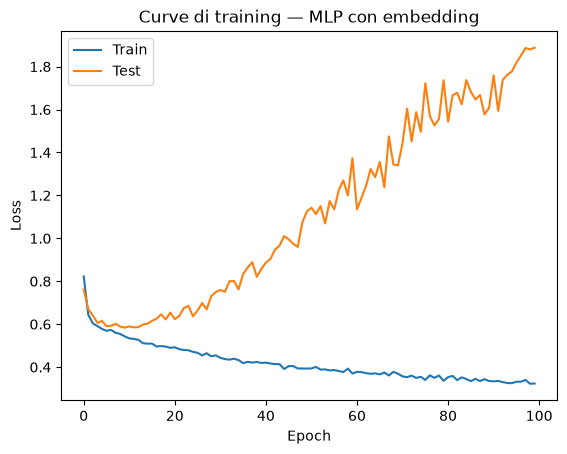

In [5]:
# Aggiungiamo il monitoraggio della loss di test durante il training, per capire se il modello sta overfittando o se aveva semplicemente bisogno di più epoche
def evaluate_loss(model, loader, criterion):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        for x_num, x_cat, y in loader:
            logits = model(x_num, x_cat)
            loss = criterion(logits, y)
            total_loss += loss.item()
    return total_loss / len(loader)


# Ripetiamo il training, questa volta monitorando entrambe le loss
model = MLPWithEmbeddings(num_numeric=len(FEATURE_COL), cat_vocab_sizes=cat_vocab_sizes)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

N_EPOCHS = 100  # raddoppiati, per vedere se serviva più tempo
train_losses, test_losses = [], []

for epoch in range(N_EPOCHS):
    model.train()
    epoch_loss = 0
    for x_num, x_cat, y in train_loader:
        optimizer.zero_grad()
        logits = model(x_num, x_cat)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    train_losses.append(epoch_loss / len(train_loader))
    test_losses.append(evaluate_loss(model, test_loader, criterion))

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{N_EPOCHS} — train loss: {train_losses[-1]:.4f}, test loss: {test_losses[-1]:.4f}")

import matplotlib.pyplot as plt
plt.plot(train_losses, label="Train")
plt.plot(test_losses, label="Test")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("Curve di training — MLP con embedding")
plt.show()

## Correzione: early stopping

Il training esteso a 100 epoch ha rivelato overfitting marcato: la loss di test cresce costantemente dopo circa l'epoch 10-15, mentre  quella di training continua a scendere. Applichiamo early stopping: fermiamo il training quando la loss di test smette di migliorare e recuperiamo i pesi del punto migliore, non quelli dell'ultima epoch.

In [6]:
model = MLPWithEmbeddings(num_numeric=len(FEATURE_COL), cat_vocab_sizes=cat_vocab_sizes)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)

N_EPOCHS = 100
patience = 10  # quante epoch aspettare senza miglioramento prima di fermarsi
best_test_loss = float("inf")
epochs_without_improvement = 0
best_model_state = None

train_losses, test_losses = [], []

for epoch in range(N_EPOCHS):
    model.train()
    epoch_loss = 0
    for x_num, x_cat, y in train_loader:
        optimizer.zero_grad()
        logits = model(x_num, x_cat)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    train_losses.append(epoch_loss / len(train_loader))
    test_loss = evaluate_loss(model, test_loader, criterion)
    test_losses.append(test_loss)

    # Se la loss di test migliora, salviamo lo stato del modello
    # (i pesi) a QUESTO punto — non necessariamente l'ultimo, ma il
    # migliore visto finora
    if test_loss < best_test_loss:
        best_test_loss = test_loss
        epochs_without_improvement = 0
        best_model_state = {k: v.clone() for k, v in model.state_dict().items()}
    else:
        epochs_without_improvement += 1

    if (epoch + 1) % 5 == 0:
        print(f"Epoch {epoch+1}/{N_EPOCHS} — train loss: {train_losses[-1]:.4f}, test loss: {test_loss:.4f}")

    # Se non migliora da troppe epoch consecutive, ci fermiamo prima
    # di sprecare tempo e di peggiorare ulteriormente
    if epochs_without_improvement >= patience:
        print(f"\nEarly stopping all'epoch {epoch+1} (nessun miglioramento da {patience} epoch)")
        break

# Ripristiniamo i pesi del MIGLIOR modello visto durante il training,
# non quelli dell'ultima epoch (che sono già in overfitting)
if best_model_state is not None:
    model.load_state_dict(best_model_state)
else:
    raise RuntimeError("No valid best model state was saved during training.")
print(f"\nMiglior test loss: {best_test_loss:.4f}")

Epoch 5/100 — train loss: 0.5927, test loss: 0.5774
Epoch 10/100 — train loss: 0.5419, test loss: 0.5793
Epoch 15/100 — train loss: 0.5048, test loss: 0.6009

Early stopping all'epoch 18 (nessun miglioramento da 10 epoch)

Miglior test loss: 0.5721


In [7]:
model.eval()
all_probas = []
with torch.no_grad():
    for x_num, x_cat, y in test_loader:
        logits = model(x_num, x_cat)
        probas = torch.sigmoid(logits)
        all_probas.append(probas.numpy())

y_proba = np.concatenate(all_probas)

best = find_best_threshold_np(y_test, y_proba)
print(f"MLP con embedding (early stopping) — soglia {best['threshold']:.2f}: "
      f"precision {best['precision']:.3f}, recall {best['recall']:.3f}, F1 {best['f1']:.3f}")
print(f"\nConfronto — XGBoost (baseline): precision 0.636, recall 0.820, F1 0.717")

MLP con embedding (early stopping) — soglia 0.70: precision 0.552, recall 0.811, F1 0.657

Confronto — XGBoost (baseline): precision 0.636, recall 0.820, F1 0.717
